# Análise de Sentimentos - Métodos baseados em Recursos Léxicos

# Instalando e Importando Bibliotecas


### Pandas e Numpy

In [ ]:
import pandas as pd
import numpy as np

### NLTK
* Apoio ao pré-processamento de textos (tokenização, stopwords, radicalização)

In [ ]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('rslp')
from nltk.tokenize import word_tokenize
from nltk.tokenize import sent_tokenize
from nltk.stem.porter import *

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package rslp to /root/nltk_data...
[nltk_data]   Unzipping stemmers/rslp.zip.


### TextBlob
TextBlob: Simplified Text Processing

https://github.com/sloria/textblob

In [ ]:
!pip install -U textblob
from textblob import TextBlob

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 626.3/626.3 kB 6.7 MB/s eta 0:00:00
  Attempting uninstall: textblob
    Found existing installation: textblob 0.17.1
    Uninstalling textblob-0.17.1:
      Successfully uninstalled textblob-0.17.1


### VADER

VADER (Valence Aware Dictionary and sEntiment Reasoner) is a lexicon and rule-based sentiment analysis tool that is specifically attuned to sentiments expressed in social media.

https://github.com/cjhutto/vaderSentiment

* Hutto, C.J. & Gilbert, E.E. (2014). VADER: A Parsimonious Rule-based Model for Sentiment Analysis of Social Media Text. Eighth International Conference on Weblogs and Social Media (ICWSM-14). Ann Arbor, MI, June 2014. https://ojs.aaai.org/index.php/ICWSM/article/view/14550


In [ ]:
!pip install vaderSentiment
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 2.7 MB/s eta 0:00:00


### Sklearn

In [ ]:
from sklearn.metrics import classification_report


# Análise de Sentimentos usando Léxicos

### TextBlob

#### Analisando todo o documento

In [ ]:
review = '''
I bought an iPhone a few days ago.
It was such a nice phone.
The touch screen was really cool.
The voice quality was clear too.
Although the battery life was not long, that is ok for me.
However, my mother was mad with me as I did not tell her before I bought it.
She also thought the phone was too expensive, and wanted me to return it to the shop.'''

doc = TextBlob(review)


In [ ]:
print('Sentimento: ',doc.sentiment.polarity)


Sentimento:  0.027777777777777776


In [ ]:
sum = 0
counter = 0
L = []
for word in doc.sentiment_assessments[2]:
  print([word[0][0],word[1]])
  sum += word[1]
  counter += 1
  L.append([word[0][0],word[1]])
print(sum/counter)

['few', -0.2]
['such', 0.0]
['nice', 0.6]
['really', 0.35]
['clear', 0.10000000000000002]
['not', 0.025]
['ok', 0.5]
['mad', -0.625]
['expensive', -0.5]
0.027777777777777776


In [ ]:
import pandas as pd
df = pd.DataFrame(L)
df.columns = ['word','sentiment_score']
df

,word,sentiment_score
0,few,-0.200
1,such,0.000
2,nice,0.600
3,really,0.350
4,clear,0.100
5,not,0.025
6,ok,0.500
7,mad,-0.625
8,expensive,-0.500


#### Analisando por sentenças do documento

In [ ]:
L = []
for sentence in doc.sentences:
  print(sentence)
  print('Sentimento: ',sentence.sentiment.polarity)
  print('--')
  L.append((str(sentence),sentence.sentiment.polarity))


I bought an iPhone a few days ago.
Sentimento:  -0.2
--
It was such a nice phone.
Sentimento:  0.3
--
The touch screen was really cool.
Sentimento:  0.35
--
The voice quality was clear too.
Sentimento:  0.10000000000000002
--
Although the battery life was not long, that is ok for me.
Sentimento:  0.2625
--
However, my mother was mad with me as I did not tell her before I bought it.
Sentimento:  -0.625
--
She also thought the phone was too expensive, and wanted me to return it to the shop.
Sentimento:  -0.5
--


#### Limitação com inversores de sentimento

In [ ]:
doc = TextBlob('I really like this book!')
doc.sentiment.polarity

0.25

In [ ]:
doc = TextBlob("I don't really like this book")
doc.sentiment.polarity

0.2

### VADER

In [ ]:
analyzer = SentimentIntensityAnalyzer()


review = '''I bought an iPhone a few days ago.
It was such a nice phone.
The touch screen was really cool.
The voice quality was clear too.
Although the battery life was not long, that is ok for me.
However, my mother was mad with me as I did not tell her before I bought it.
She also thought the phone was too expensive, and wanted me to return it to the shop.'''

L = []
for sentence in sent_tokenize(review):
  vs = analyzer.polarity_scores(sentence)
  item = [sentence,vs['neg'],vs['neu'],vs['pos']]
  L.append(item)

In [ ]:
df = pd.DataFrame(L)
df.columns = ['sentence','negative','neutral','positive']
df

,sentence,negative,neutral,positive
0,I bought an iPhone a few days ago.,0.000,1.000,0.000
1,It was such a nice phone.,0.000,0.641,0.359
2,The touch screen was really cool.,0.000,0.659,0.341
3,The voice quality was clear too.,0.000,0.658,0.342
4,"Although the battery life was not long, that i...",0.000,0.833,0.167
5,"However, my mother was mad with me as I did no...",0.167,0.833,0.000
6,"She also thought the phone was too expensive, ...",0.000,1.000,0.000


#### Testando inversores de sentimento

In [ ]:
vs = analyzer.polarity_scores('I really like this book!')
print('negative:',vs['neg'],
      'neutral:',vs['neu'],
      'positive:',vs['pos'])

negative: 0.0 neutral: 0.565 positive: 0.435


In [ ]:
vs = analyzer.polarity_scores("I don't really like this book")
print('negative:',vs['neg'],
      'neutral:',vs['neu'],
      'positive:',vs['pos'])

negative: 0.318 neutral: 0.682 positive: 0.0


# Analisando Posts


In [ ]:
!gdown --id 114yGPdgJcrw0lpK1xrd1MdJbBohGP9TJ

/usr/local/lib/python3.10/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=114yGPdgJcrw0lpK1xrd1MdJbBohGP9TJ
To: /content/posts_test.csv
100% 567k/567k [00:00<00:00, 102MB/s]


In [ ]:
df_test = pd.read_csv('posts_test.csv')
df_test

,text,label
0,James DauntÂs taking it well. Abusing his sta...,negative
1,People who overcame panic and have decided to ...,negative
2,"In 2019, the new presidents of Mexico and Arge...",negative
3,The German Chancellor nailed it with this line...,positive
4,New Jersey man faces multiple terror charges a...,negative
...,...,...
2395,General drop in the #ElectricityMarkets prices...,negative
2396,@Nouriel How does America not go into a deflat...,negative
2397,@realDonaldTrump @WhiteHouse @POTUS @VP \r\r\n...,positive
2398,Good morning.\r\r\n\r\r\n Covid 19 is real ple...,positive


<Axes: >

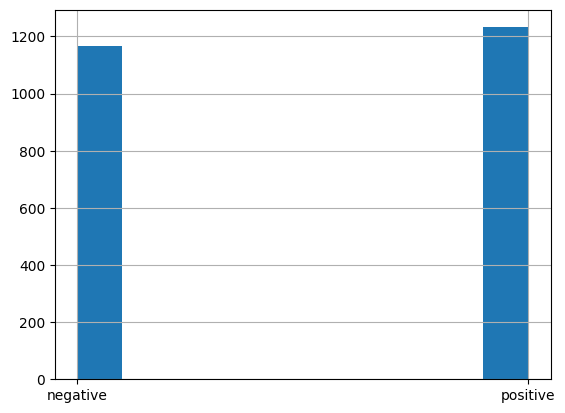

In [ ]:
df_test.label.hist()

### TextBlob

In [ ]:
y_true = []
y_pred = []

for index,row in df_test.iterrows():
  y_true.append(row['label'])

  label = ''
  doc = TextBlob(row['text'])
  if doc.sentiment.polarity > 0: label='positive'
  else: label='negative'

  y_pred.append(label)

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

    negative       0.74      0.68      0.71      1168
    positive       0.72      0.77      0.74      1232

    accuracy                           0.72      2400
   macro avg       0.73      0.72      0.72      2400
weighted avg       0.73      0.72      0.72      2400



### VADER

In [ ]:
y_true = []
y_pred = []

for index,row in df_test.iterrows():
  y_true.append(row['label'])

  label = ''

  vs = analyzer.polarity_scores(row['text'])

  if vs['pos'] > vs['neg']: label='positive'
  else: label='negative'

  y_pred.append(label)

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

    negative       0.99      0.98      0.98      1168
    positive       0.98      0.99      0.99      1232

    accuracy                           0.98      2400
   macro avg       0.99      0.98      0.98      2400
weighted avg       0.99      0.98      0.98      2400

